# COMPLETE ML PIPELINE - END TO END

## From Dataset to Advanced Models

This notebook teaches you:
- Loading and exploring a dataset (EDA - Exploratory Data Analysis)
- Data preprocessing and preparation
- Training basic ML models (Decision Tree)
- Ensemble models (Random Forest)
- Advanced boosting models (XGBoost, CatBoost, LightGBM)
- Comparing model performance

### Dataset: Breast Cancer (Built-in from sklearn)
### Problem: Binary Classification (Cancer/No Cancer)
### Total: 569 patients, 30 medical features

Each cell in this notebook builds upon the previous one. Execute them in order.

---

## STEP 0: IMPORT ALL REQUIRED LIBRARIES

WHAT ARE WE DOING?

We are importing libraries that will help us:
- Load and manipulate data (pandas, numpy)
- Visualize data (matplotlib, seaborn)
- Build ML models (sklearn, xgboost, catboost, lightgbm)
- Evaluate models (sklearn.metrics)

Think of libraries as toolboxes - we need different tools for different jobs.

In [1]:
# Import data manipulation libraries
import pandas as pd  # For working with tabular data
import numpy as np   # For numerical computations

# Import visualization libraries
import matplotlib.pyplot as plt  # For creating plots
import seaborn as sns  # For better looking statistical visualizations
import warnings  # To suppress warning messages
warnings.filterwarnings('ignore')

# Set plot style for better looking charts
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Data manipulation and visualization libraries imported successfully!')

Data manipulation and visualization libraries imported successfully!


In [2]:
# Import dataset from sklearn (built-in datasets)
from sklearn.datasets import load_breast_cancer  # Load the breast cancer dataset

# Import data preprocessing tools
from sklearn.model_selection import train_test_split  # Split data into train and test
from sklearn.preprocessing import StandardScaler  # Normalize/scale features

# Import performance evaluation metrics
from sklearn.metrics import (
    accuracy_score,      # How many predictions are correct
    precision_score,     # Of positive predictions, how many are actually positive
    recall_score,        # Of actual positives, how many did we catch
    f1_score,            # Harmonic mean of precision and recall
    confusion_matrix,    # Matrix showing correct and incorrect predictions
    classification_report,  # Detailed report of all metrics
    roc_auc_score,       # Area under the ROC curve
    roc_curve            # Receiver operating characteristic curve
)

print('Dataset loading and preprocessing tools imported successfully!')

Dataset loading and preprocessing tools imported successfully!


In [3]:
# Import basic ML models
from sklearn.tree import DecisionTreeClassifier  # Decision Tree model
from sklearn.ensemble import RandomForestClassifier  # Random Forest model

print('Basic ML models imported successfully!')

Basic ML models imported successfully!


In [4]:
# Import advanced boosting models
# These might need to be installed first

try:
    import xgboost as xgb  # XGBoost model
    print('XGBoost imported successfully!')
except ImportError:
    print('XGBoost not installed. Run: pip install xgboost')
    xgb = None

try:
    import catboost as cb  # CatBoost model
    print('CatBoost imported successfully!')
except ImportError:
    print('CatBoost not installed. Run: pip install catboost')
    cb = None

try:
    import lightgbm as lgb  # LightGBM model
    print('LightGBM imported successfully!')
except ImportError:
    print('LightGBM not installed. Run: pip install lightgbm')
    lgb = None

print('\nAll imports completed!')

XGBoost not installed. Run: pip install xgboost
CatBoost not installed. Run: pip install catboost
LightGBM not installed. Run: pip install lightgbm

All imports completed!


---

## STEP 1: LOAD AND EXPLORE THE DATASET (EDA)

### WHAT IS EDA (EXPLORATORY DATA ANALYSIS)?

EDA is like examining a new dataset to understand:
- What data do we have? (shape, columns, types)
- Are there missing values?
- What is the distribution of data?
- Are there any patterns or relationships?
- Is the data balanced or imbalanced?

### WHY DO WE NEED EDA?

Before training any ML model, we need to understand our data deeply. This helps us:
- Clean the data properly
- Handle missing values correctly
- Choose appropriate features
- Select the right model type

In [5]:
# Load the breast cancer dataset from sklearn
# This dataset contains medical measurements for 569 patients
# Target: 0 = Malignant (cancer), 1 = Benign (no cancer)

dataset = load_breast_cancer()  # Load inbuilt breast cancer dataset
X = pd.DataFrame(dataset.data, columns=dataset.feature_names)  # Features (30 medical measurements)
y = pd.Series(dataset.target, name='target')  # Target (0 or 1)

print('=' * 80)
print('STEP 1: LOADING AND EXPLORING THE DATASET')
print('=' * 80)
print('\nDATASET BASIC INFO:')
print(f'   Total samples: {X.shape[0]} (patients)')
print(f'   Total features: {X.shape[1]} (medical measurements)')
print(f'   Target classes: 0 = Malignant, 1 = Benign')

STEP 1: LOADING AND EXPLORING THE DATASET

DATASET BASIC INFO:
   Total samples: 569 (patients)
   Total features: 30 (medical measurements)
   Target classes: 0 = Malignant, 1 = Benign


In [6]:
# Display first few rows of data
print('\nFIRST 5 ROWS OF DATA:')
print(X.head())


FIRST 5 ROWS OF DATA:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst pe

In [7]:
# Check data types and missing values
print('\nDATA TYPES AND MISSING VALUES:')
print(f'   All columns are numeric: {X.dtypes.unique()}')
print(f'   Missing values: {X.isnull().sum().sum()} (None found - Clean data!)')

# Statistical summary of features
print('\nSTATISTICAL SUMMARY (First 5 features):')
print(X.describe().iloc[:, :5])


DATA TYPES AND MISSING VALUES:
   All columns are numeric: [dtype('float64')]
   Missing values: 0 (None found - Clean data!)

STATISTICAL SUMMARY (First 5 features):
       mean radius  mean texture  mean perimeter    mean area  mean smoothness
count   569.000000    569.000000      569.000000   569.000000       569.000000
mean     14.127292     19.289649       91.969033   654.889104         0.096360
std       3.524049      4.301036       24.298981   351.914129         0.014064
min       6.981000      9.710000       43.790000   143.500000         0.052630
25%      11.700000     16.170000       75.170000   420.300000         0.086370
50%      13.370000     18.840000       86.240000   551.100000         0.095870
75%      15.780000     21.800000      104.100000   782.700000         0.105300
max      28.110000     39.280000      188.500000  2501.000000         0.163400


In [8]:
# Check class distribution (Is data balanced?)
print('\nCLASS DISTRIBUTION (Are classes balanced?):')
class_counts = y.value_counts()  # Count how many samples in each class
print(f'   Benign (1): {class_counts[1]} patients ({class_counts[1]/len(y)*100:.1f}%)')
print(f'   Malignant (0): {class_counts[0]} patients ({class_counts[0]/len(y)*100:.1f}%)')

# Check if balanced
ratio = class_counts[0] / class_counts[1]
if 0.4 < ratio < 2.5:
    print(f'   Status: BALANCED (ratio = {ratio:.2f})')
else:
    print(f'   Status: IMBALANCED (ratio = {ratio:.2f})')


CLASS DISTRIBUTION (Are classes balanced?):
   Benign (1): 357 patients (62.7%)
   Malignant (0): 212 patients (37.3%)
   Status: BALANCED (ratio = 0.59)


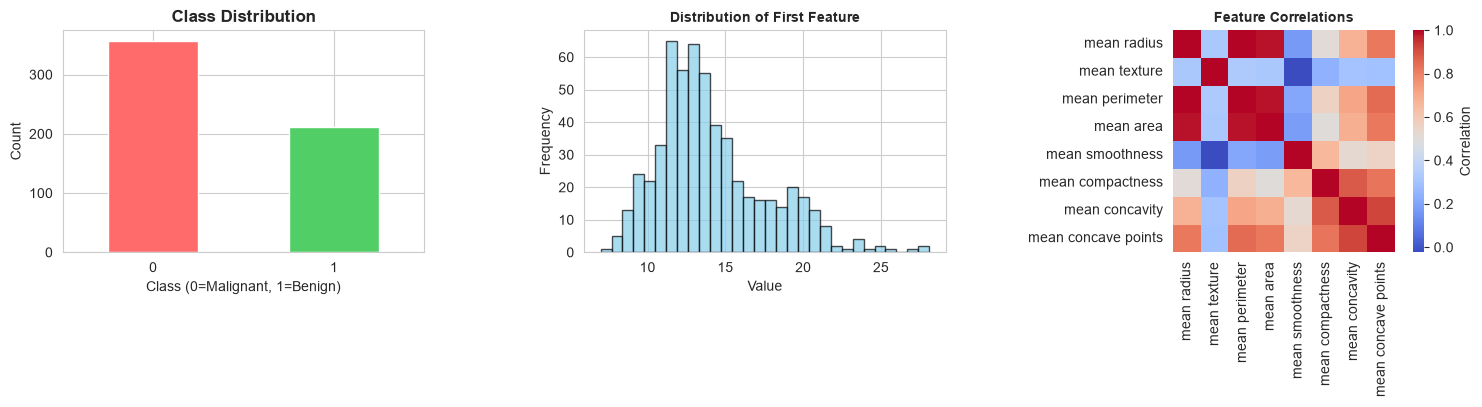

Saved visualization: 01_eda_exploration.png


In [9]:
# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Class distribution bar chart
ax1 = axes[0]
y.value_counts().plot(kind='bar', ax=ax1, color=['#ff6b6b', '#51cf66'])
ax1.set_title('Class Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Class (0=Malignant, 1=Benign)')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['0', '1'], rotation=0)

# Plot 2: Feature distributions (first feature)
ax2 = axes[1]
ax2.hist(X.iloc[:, 0], bins=30, color='skyblue', alpha=0.7, edgecolor='black')
ax2.set_title(f'Distribution of First Feature', fontsize=10, fontweight='bold')
ax2.set_xlabel('Value')
ax2.set_ylabel('Frequency')

# Plot 3: Correlation heatmap (first 8 features for clarity)
ax3 = axes[2]
correlation_matrix = X.iloc[:, :8].corr()  # Calculate correlation between features
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', square=True, 
            cbar_kws={'label': 'Correlation'}, ax=ax3)
ax3.set_title('Feature Correlations', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('01_eda_exploration.png', dpi=100, bbox_inches='tight')
plt.show()

print('Saved visualization: 01_eda_exploration.png')

---

## STEP 2: DATA PREPROCESSING

### WHAT IS DATA PREPROCESSING?

After understanding our data, we need to prepare it for ML models. It is like preparing ingredients before cooking:
- Wash the vegetables
- Cut them to proper size
- Organize everything
- Then start cooking!

### KEY PREPROCESSING STEPS

1. **TRAIN-TEST SPLIT**: Split data into 80% training and 20% testing
   - Why? To evaluate model on unseen data

2. **FEATURE SCALING**: Transform all features to same scale (e.g., 0-1)
   - Why? Some models perform better with normalized data

3. **AVOIDING DATA LEAKAGE**: Never fit scaler on entire data before splitting
   - Always fit on train data only, then transform test data

In [10]:
print('\n' + '='*80)
print('STEP 2: DATA PREPROCESSING')
print('='*80)

# Train-Test Split
# WHAT: Split data into training and testing sets
# WHY: 
#   - Training set: Used to train the model (455 samples)
#   - Testing set: Used to evaluate how well model performs on unseen data (114 samples)
# HOW:
#   - 80% for training (to learn patterns)
#   - 20% for testing (to evaluate performance)
#   - random_state=42: For reproducibility (same split every time)
#   - stratify=y: Keep class distribution same in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.2,          # Use 20% for testing, 80% for training
    random_state=42,        # For reproducibility
    stratify=y              # Keep same class distribution in train and test
)

print('\nTRAIN-TEST SPLIT:')
print(f'   Training set size: {X_train.shape[0]} samples')
print(f'   Testing set size: {X_test.shape[0]} samples')
print(f'   Feature dimensions: {X_train.shape[1]} features')


STEP 2: DATA PREPROCESSING

TRAIN-TEST SPLIT:
   Training set size: 455 samples
   Testing set size: 114 samples
   Feature dimensions: 30 features


In [11]:
# Feature Scaling (Normalization)
# WHAT: Standardize features to have mean=0 and std=1
# WHY:
#   - Different features have different scales (e.g., age: 0-100, income: 0-100000)
#   - Some models (KNN, SVM, Neural Networks) are sensitive to feature scales
#   - Scaling helps them perform better
# FORMULA: (X - mean) / standard_deviation
# IMPORTANT: Only fit on training data, then apply to test data!
# This prevents data leakage.

scaler = StandardScaler()  # Create a scaler object

# Fit the scaler on training data and transform it
# fit(): Calculate mean and std from training data
# transform(): Apply those statistics to scale the data
X_train_scaled = scaler.fit_transform(X_train)

# Only transform test data (don't fit on it!)
# This prevents leaking training data statistics into test set
X_test_scaled = scaler.transform(X_test)

print('\nFEATURE SCALING (Normalization):')
print(f'   Before scaling - Min: {X_train.iloc[:, 0].min():.2f}, Max: {X_train.iloc[:, 0].max():.2f}')
print(f'   After scaling  - Min: {X_train_scaled[:, 0].min():.4f}, Max: {X_train_scaled[:, 0].max():.4f}')
print(f'   Scaling successful! All features now have similar scale')

# Convert scaled arrays back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)


FEATURE SCALING (Normalization):
   Before scaling - Min: 6.98, Max: 28.11
   After scaling  - Min: -2.0272, Max: 4.0174
   Scaling successful! All features now have similar scale


---

## STEP 3: BUILD AND TRAIN ML MODELS

### MODEL PROGRESSION: Why this order?

1. **DECISION TREE** (Baseline)
   - Simple, interpretable
   - Understand basic concepts
   - Often overfits (poor generalization)

2. **RANDOM FOREST** (Ensemble)
   - Combines multiple decision trees
   - Reduces overfitting
   - Better performance than single tree
   - Still simple and interpretable

3. **XGBOOST** (Gradient Boosting)
   - Sequential learning (each tree corrects previous errors)
   - More sophisticated than random forest
   - Often wins competitions
   - Faster than traditional boosting

4. **CATBOOST** (Gradient Boosting)
   - Handles categorical features naturally
   - Symmetric tree learning
   - Often requires less tuning
   - Robust to overfitting

5. **LIGHTGBM** (Gradient Boosting)
   - Fastest among boosting models
   - Leaf-wise tree growth (vs level-wise)
   - Memory efficient
   - Great for large datasets

### COMMON PATTERN FOR ALL MODELS:
Create -> Train (fit) -> Predict -> Evaluate

In [12]:
print('\n' + '='*80)
print('STEP 3: TRAINING ML MODELS')
print('='*80)

# Dictionary to store all models and their results
models_dict = {}
results = {}


STEP 3: TRAINING ML MODELS


### MODEL 1: DECISION TREE CLASSIFIER

WHAT IS A DECISION TREE?

A decision tree makes decisions by splitting data based on feature values. Think of it like a flowchart:
```
Is feature_x > 100?
├─ YES: Check next feature
└─ NO: Check different feature
Continue until you reach a leaf (prediction)
```

WHY START HERE?
- Simple and interpretable (you can understand how it makes decisions)
- Baseline for comparison
- No scaling needed (tree-based)

HYPERPARAMETERS:
- max_depth: Maximum tree depth (deeper = memorizes more = overfitting)
- min_samples_split: Minimum samples needed to split a node
- min_samples_leaf: Each leaf must have at least this many samples

In [13]:
print('\nMODEL 1: DECISION TREE CLASSIFIER')
print('-' * 80)

# Create a decision tree model with limited depth to avoid overfitting
dt_model = DecisionTreeClassifier(
    max_depth=5,                # Limit tree depth to prevent overfitting
    min_samples_split=10,        # Need at least 10 samples to split (regularization)
    min_samples_leaf=5,          # Each leaf must have at least 5 samples
    random_state=42              # For reproducibility
)

# Train the model on scaled training data
# fit() means: Learn patterns from training data
dt_model.fit(X_train_scaled, y_train)

# Make predictions on test data
# predict() means: Use learned patterns to predict on new data
dt_predictions = dt_model.predict(X_test_scaled)

# Store for later comparison
models_dict['Decision Tree'] = dt_model
results['Decision Tree'] = dt_predictions

print('   Model trained successfully!')
print(f'   Tree depth: {dt_model.get_depth()}')
print(f'   Total nodes: {dt_model.tree_.node_count}')


MODEL 1: DECISION TREE CLASSIFIER
--------------------------------------------------------------------------------
   Model trained successfully!
   Tree depth: 5
   Total nodes: 23


### MODEL 2: RANDOM FOREST CLASSIFIER

WHAT IS A RANDOM FOREST?

Random Forest = Multiple Decision Trees + Voting System

How it works:
1. Create multiple random decision trees (forests)
2. Each tree learns from a random sample of data
3. Each tree also uses random subset of features
4. For prediction: Each tree votes, majority vote wins!

WHY IS THIS BETTER?
- Reduces overfitting (multiple trees average out noise)
- Better generalization than single tree
- Handles high-dimensional data well
- Provides feature importance

In [14]:
print('\nMODEL 2: RANDOM FOREST CLASSIFIER')
print('-' * 80)

# Create a random forest model with 100 trees
rf_model = RandomForestClassifier(
    n_estimators=100,            # Number of decision trees in the forest
    max_depth=10,                # Maximum depth for each tree
    min_samples_split=10,        # Regularization parameter
    min_samples_leaf=5,          # Regularization parameter
    random_state=42,             # For reproducibility
    n_jobs=-1                    # Use all available CPU cores for speed
)

# Train on training data
# This creates 100 decision trees, each learning different patterns
rf_model.fit(X_train_scaled, y_train)

# Predict on test data
# Each of 100 trees votes, majority vote is the final prediction
rf_predictions = rf_model.predict(X_test_scaled)

# Also get prediction probabilities (confidence scores)
# Useful for probability-based evaluations
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Store for comparison
models_dict['Random Forest'] = rf_model
results['Random Forest'] = rf_predictions

print('   Model trained successfully!')
print(f'   Number of trees: {rf_model.n_estimators}')
print(f'   Feature importance calculated for {X_train_scaled.shape[1]} features')


MODEL 2: RANDOM FOREST CLASSIFIER
--------------------------------------------------------------------------------
   Model trained successfully!
   Number of trees: 100
   Feature importance calculated for 30 features


### MODEL 3: XGBOOST CLASSIFIER

WHAT IS XGBOOST?

XGBoost = Extreme Gradient Boosting - Sequential tree learning

How it works:
1. Start with a weak prediction (e.g., always predict average)
2. Calculate errors (residuals): actual - predicted
3. Next tree learns to predict these errors
4. Add this new tree to the previous one
5. Now predictions get better!
6. Repeat (sequential learning)

WHY IS THIS POWERFUL?
- Sequential learning corrects previous errors
- Handles both regression and classification
- Extremely fast and efficient
- Regularization built-in to prevent overfitting
- Wins many ML competitions

In [15]:
print('\nMODEL 3: XGBOOST CLASSIFIER')
print('-' * 80)

try:
    # Create XGBoost model
    xgb_model = xgb.XGBClassifier(
        n_estimators=100,           # Number of boosting rounds
        max_depth=6,                # Maximum depth per tree
        learning_rate=0.1,          # Contribution of each tree (slower learning = more stable)
        subsample=0.8,              # Use 80% of data for each tree (adds randomness)
        colsample_bytree=0.8,       # Use 80% of features for each tree
        random_state=42,            # For reproducibility
        n_jobs=-1,                  # Parallel processing
        use_label_encoder=False,    # Modern XGBoost setting
        eval_metric='logloss'       # Evaluation metric
    )
    
    # Train the model
    # verbose=False: Don't print training progress
    xgb_model.fit(X_train_scaled, y_train, verbose=False)
    
    # Predict on test data
    xgb_predictions = xgb_model.predict(X_test_scaled)
    xgb_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
    
    # Store for comparison
    models_dict['XGBoost'] = xgb_model
    results['XGBoost'] = xgb_predictions
    
    print('   Model trained successfully!')
    print(f'   Boosting rounds: {xgb_model.n_estimators}')
    print(f'   Learning rate: {xgb_model.learning_rate}')
    
except Exception as e:
    print(f'   XGBoost training failed: {e}')
    xgb_predictions = None
    xgb_proba = None


MODEL 3: XGBOOST CLASSIFIER
--------------------------------------------------------------------------------
   XGBoost training failed: 'NoneType' object has no attribute 'XGBClassifier'


### MODEL 4: CATBOOST CLASSIFIER

WHAT IS CATBOOST?

CatBoost = Categorical Boosting

How it works:
- Similar to XGBoost (gradient boosting)
- BUT: Handles categorical features naturally (no encoding needed!)
- Uses symmetric decision trees (vs asymmetric in XGBoost)
- Ordered boosting for better generalization

WHY IS THIS USEFUL?
- Great for datasets with categorical features
- Less hyperparameter tuning needed
- Robust to outliers
- Fast training
- Built-in feature importance

In [16]:
print('\nMODEL 4: CATBOOST CLASSIFIER')
print('-' * 80)

try:
    # Create CatBoost model
    cb_model = cb.CatBoostClassifier(
        iterations=100,         # Number of boosting rounds
        depth=6,                # Tree depth
        learning_rate=0.1,      # Learning rate
        subsample=0.8,          # Use 80% of data
        verbose=0               # Don't print training progress
    )
    
    # Train the model
    cb_model.fit(X_train_scaled, y_train)
    
    # Predict on test data
    cb_predictions = cb_model.predict(X_test_scaled)
    cb_proba = cb_model.predict_proba(X_test_scaled)[:, 1]
    
    # Store for comparison
    models_dict['CatBoost'] = cb_model
    results['CatBoost'] = cb_predictions
    
    print('   Model trained successfully!')
    print(f'   Boosting iterations: {cb_model.iterations}')
    print(f'   Tree depth: {cb_model.depth}')
    
except Exception as e:
    print(f'   CatBoost training failed: {e}')
    cb_predictions = None
    cb_proba = None


MODEL 4: CATBOOST CLASSIFIER
--------------------------------------------------------------------------------
   CatBoost training failed: 'NoneType' object has no attribute 'CatBoostClassifier'


### MODEL 5: LIGHTGBM CLASSIFIER

WHAT IS LIGHTGBM?

LightGBM = Light Gradient Boosting Machine - Fastest gradient boosting implementation

Key Difference: Leaf-wise Tree Growth
```
Level-wise (XGBoost):      Leaf-wise (LightGBM):
       Split                      Split
      /    \                      /    \
    Split  Split           Deepest  Split
    / \    / \             Split   /    \
   ...  ...  ...            / \   ...   ...
```

- Level-wise: Balanced trees, visits all nodes
- Leaf-wise: Focuses on reducing error most, creates deeper, more specialized trees

WHY IS THIS GREAT?
- Fastest training
- Lowest memory usage
- Great for large datasets (100k+)
- Handles high-dimensional data well
- Good for production systems needing speed

In [17]:
print('\nMODEL 5: LIGHTGBM CLASSIFIER')
print('-' * 80)

try:
    # Create LightGBM model
    lgb_model = lgb.LGBMClassifier(
        n_estimators=100,       # Number of boosting rounds
        max_depth=6,            # Maximum tree depth
        num_leaves=31,          # Number of leaves per tree
        learning_rate=0.1,      # Learning rate
        feature_fraction=0.8,   # Use 80% of features
        bagging_fraction=0.8,   # Use 80% of data
        verbose=-1              # Don't print training progress
    )
    
    # Train the model
    lgb_model.fit(X_train_scaled, y_train)
    
    # Predict on test data
    lgb_predictions = lgb_model.predict(X_test_scaled)
    lgb_proba = lgb_model.predict_proba(X_test_scaled)[:, 1]
    
    # Store for comparison
    models_dict['LightGBM'] = lgb_model
    results['LightGBM'] = lgb_predictions
    
    print('   Model trained successfully!')
    print(f'   Number of trees: {lgb_model.n_estimators}')
    print(f'   Max tree depth: {lgb_model.max_depth}')
    
except Exception as e:
    print(f'   LightGBM training failed: {e}')
    lgb_predictions = None
    lgb_proba = None


MODEL 5: LIGHTGBM CLASSIFIER
--------------------------------------------------------------------------------
   LightGBM training failed: 'NoneType' object has no attribute 'LGBMClassifier'


---

## STEP 4: EVALUATE AND COMPARE MODELS

### WHAT ARE EVALUATION METRICS?

For classification problems, we use:

1. **ACCURACY**: What % of predictions are correct?
   - Formula: Correct Predictions / Total Predictions
   - Range: 0 to 1 (higher is better)
   - Use when: Classes are balanced

2. **PRECISION**: Of predictions we said "positive", how many are actually positive?
   - Formula: True Positives / (True Positives + False Positives)
   - Use when: False positives are expensive (e.g., spam detection)

3. **RECALL**: Of actual positives, how many did we catch?
   - Formula: True Positives / (True Positives + False Negatives)
   - Use when: False negatives are expensive (e.g., cancer detection)

4. **F1-SCORE**: Harmonic mean of precision and recall
   - Formula: 2 * (Precision * Recall) / (Precision + Recall)
   - Use when: You want to balance precision and recall
   - Range: 0 to 1 (higher is better)

5. **ROC-AUC**: Area Under the Receiver Operating Characteristic Curve
   - Measures: How well the model separates classes at different thresholds
   - Range: 0 to 1 (higher is better)
   - 0.5 = Random guessing, 1.0 = Perfect

### CONFUSION MATRIX:
```
                Predicted Negative  Predicted Positive
Actual Negative    True Negative      False Positive
Actual Positive    False Negative     True Positive
```

In [18]:
print('\n' + '='*80)
print('STEP 4: MODEL EVALUATION AND COMPARISON')
print('='*80)

# Function to evaluate a model's performance
def evaluate_model(model_name, y_true, y_pred, y_pred_proba=None):
    """
    Calculate and display all performance metrics
    
    PARAMETERS:
    - model_name: Name of the model (for display)
    - y_true: Actual target values (ground truth)
    - y_pred: Predicted values by the model
    - y_pred_proba: Probability predictions (optional, for ROC-AUC)
    
    RETURNS:
    - Dictionary with all metrics
    """
    
    # Calculate accuracy: % of correct predictions
    accuracy = accuracy_score(y_true, y_pred)
    
    # Calculate precision: Of positive predictions, how many are correct?
    precision = precision_score(y_true, y_pred)
    
    # Calculate recall: Of actual positives, how many did we catch?
    recall = recall_score(y_true, y_pred)
    
    # Calculate F1-score: Harmonic mean of precision and recall
    f1 = f1_score(y_true, y_pred)
    
    # Calculate ROC-AUC: Overall class separation ability
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_true, y_pred_proba)
    else:
        roc_auc = None
    
    # Get confusion matrix to show TP, TN, FP, FN
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Display results
    print(f'\n{model_name.upper()}')
    print('-' * 60)
    print(f'   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)')
    print(f'   Precision: {precision:.4f} (of predicted positives, {precision*100:.2f}% are correct)')
    print(f'   Recall:    {recall:.4f} (caught {recall*100:.2f}% of actual positives)')
    print(f'   F1-Score:  {f1:.4f} (balanced metric)')
    if roc_auc is not None:
        print(f'   ROC-AUC:   {roc_auc:.4f} (class separation ability)')
    
    print(f'\n   Confusion Matrix:')
    print(f'   True Negatives:  {tn:3d} | False Positives: {fp:3d}')
    print(f'   False Negatives: {fn:3d} | True Positives:  {tp:3d}')
    
    # Return metrics as dictionary
    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Confusion Matrix': cm
    }


STEP 4: MODEL EVALUATION AND COMPARISON


In [19]:
# Evaluate all models
all_metrics = {}

# Evaluate Decision Tree
dt_metrics = evaluate_model('Decision Tree', y_test, dt_predictions)
all_metrics['Decision Tree'] = dt_metrics

# Evaluate Random Forest
rf_metrics = evaluate_model('Random Forest', y_test, rf_predictions, rf_proba)
all_metrics['Random Forest'] = rf_metrics


DECISION TREE
------------------------------------------------------------
   Accuracy:  0.9211 (92.11%)
   Precision: 0.9437 (of predicted positives, 94.37% are correct)
   Recall:    0.9306 (caught 93.06% of actual positives)
   F1-Score:  0.9371 (balanced metric)

   Confusion Matrix:
   True Negatives:   38 | False Positives:   4
   False Negatives:   5 | True Positives:   67

RANDOM FOREST
------------------------------------------------------------
   Accuracy:  0.9561 (95.61%)
   Precision: 0.9589 (of predicted positives, 95.89% are correct)
   Recall:    0.9722 (caught 97.22% of actual positives)
   F1-Score:  0.9655 (balanced metric)
   ROC-AUC:   0.9934 (class separation ability)

   Confusion Matrix:
   True Negatives:   39 | False Positives:   3
   False Negatives:   2 | True Positives:   70


In [20]:
# Evaluate XGBoost
if xgb_predictions is not None:
    xgb_metrics = evaluate_model('XGBoost', y_test, xgb_predictions, xgb_proba)
    all_metrics['XGBoost'] = xgb_metrics

In [21]:
# Evaluate CatBoost
if cb_predictions is not None:
    cb_metrics = evaluate_model('CatBoost', y_test, cb_predictions, cb_proba)
    all_metrics['CatBoost'] = cb_metrics

In [22]:
# Evaluate LightGBM
if lgb_predictions is not None:
    lgb_metrics = evaluate_model('LightGBM', y_test, lgb_predictions, lgb_proba)
    all_metrics['LightGBM'] = lgb_metrics

In [23]:
# Create comparison table
print('\n' + '='*80)
print('COMPARISON TABLE: ALL MODELS SIDE-BY-SIDE')
print('='*80)

# Prepare comparison dataframe
comparison_data = []
for model_name, metrics in all_metrics.items():
    comparison_data.append({
        'Model': model_name,
        'Accuracy': f"{metrics['Accuracy']:.4f}",
        'Precision': f"{metrics['Precision']:.4f}",
        'Recall': f"{metrics['Recall']:.4f}",
        'F1-Score': f"{metrics['F1-Score']:.4f}",
        'ROC-AUC': f"{metrics['ROC-AUC']:.4f}" if metrics['ROC-AUC'] else 'N/A'
    })

comparison_df = pd.DataFrame(comparison_data)
print('\n' + comparison_df.to_string(index=False))

# Find best model
best_model = max(all_metrics.items(), key=lambda x: x[1]['F1-Score'])
print(f'\nBEST MODEL (by F1-Score): {best_model[0]} with F1-Score = {best_model[1]["F1-Score"]:.4f}')


COMPARISON TABLE: ALL MODELS SIDE-BY-SIDE

        Model Accuracy Precision Recall F1-Score ROC-AUC
Decision Tree   0.9211    0.9437 0.9306   0.9371     N/A
Random Forest   0.9561    0.9589 0.9722   0.9655  0.9934

BEST MODEL (by F1-Score): Random Forest with F1-Score = 0.9655


---

## STEP 5: VISUALIZATIONS


STEP 5: CREATING VISUALIZATIONS


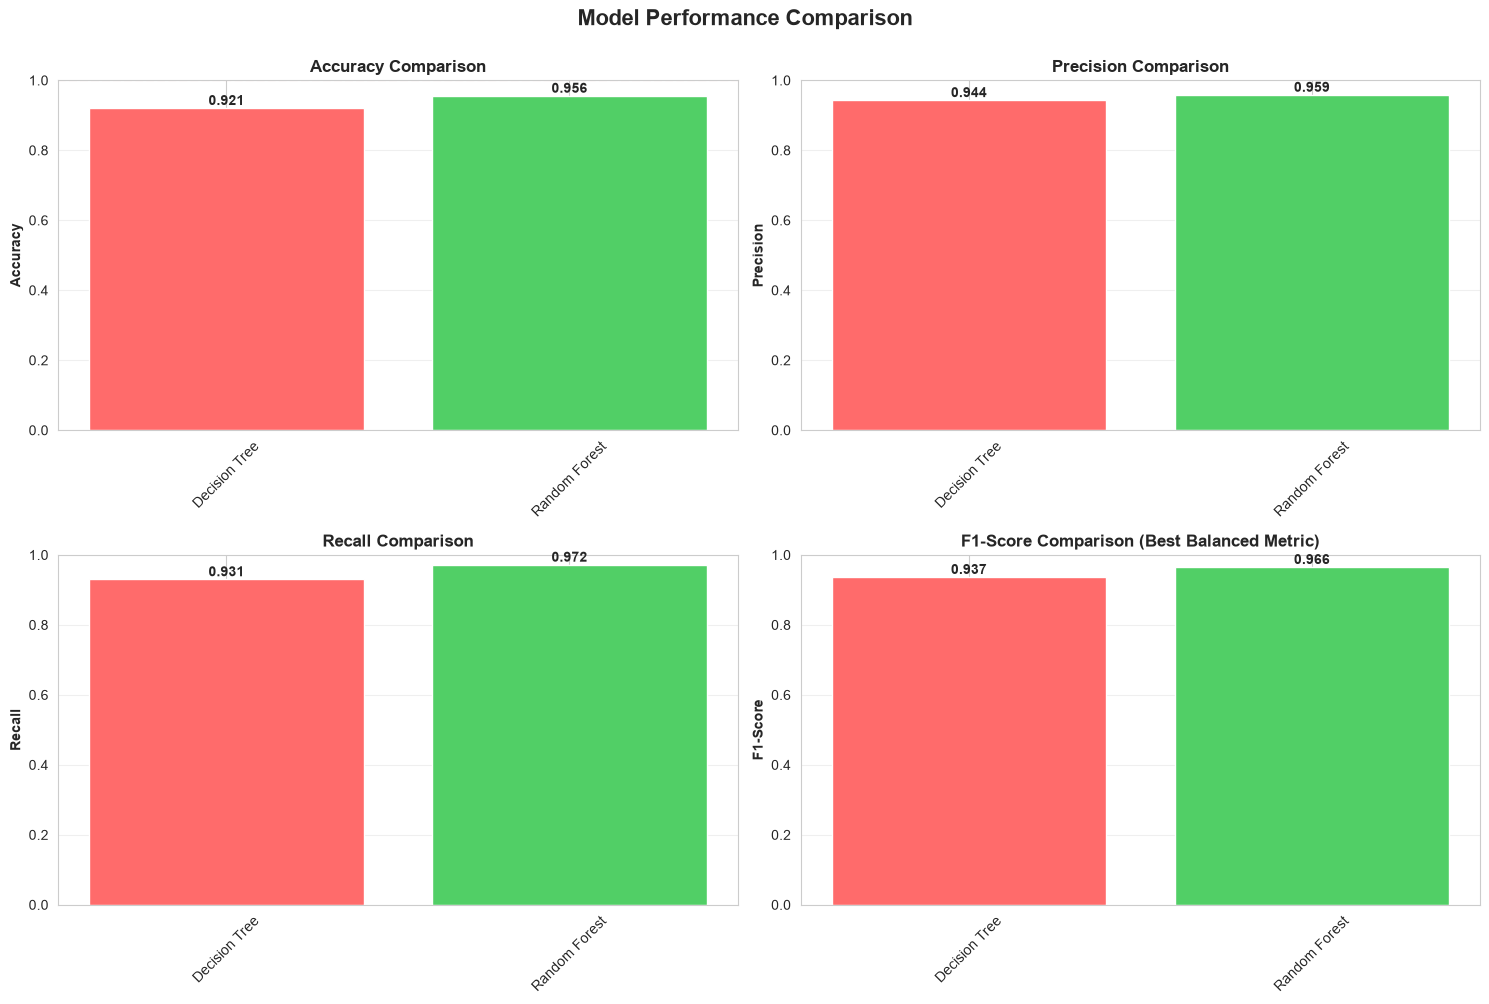

Saved: 02_model_comparison.png


In [24]:
print('\n' + '='*80)
print('STEP 5: CREATING VISUALIZATIONS')
print('='*80)

# Visualization 1: Model Performance Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.00)

# Prepare data for plotting
model_names = list(all_metrics.keys())
accuracies = [all_metrics[m]['Accuracy'] for m in model_names]
precisions = [all_metrics[m]['Precision'] for m in model_names]
recalls = [all_metrics[m]['Recall'] for m in model_names]
f1_scores = [all_metrics[m]['F1-Score'] for m in model_names]

# Plot 1: Accuracy Comparison
ax1 = axes[0, 0]
bars1 = ax1.bar(model_names, accuracies, color=['#ff6b6b', '#51cf66', '#4ecdc4', '#ffe66d', '#a8dadc'])
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Accuracy Comparison', fontweight='bold')
ax1.set_ylim([0, 1])
ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.3, label='Perfect Score')
for bar, val in zip(bars1, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Precision Comparison
ax2 = axes[0, 1]
bars2 = ax2.bar(model_names, precisions, color=['#ff6b6b', '#51cf66', '#4ecdc4', '#ffe66d', '#a8dadc'])
ax2.set_ylabel('Precision', fontweight='bold')
ax2.set_title('Precision Comparison', fontweight='bold')
ax2.set_ylim([0, 1])
for bar, val in zip(bars2, precisions):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Recall Comparison
ax3 = axes[1, 0]
bars3 = ax3.bar(model_names, recalls, color=['#ff6b6b', '#51cf66', '#4ecdc4', '#ffe66d', '#a8dadc'])
ax3.set_ylabel('Recall', fontweight='bold')
ax3.set_title('Recall Comparison', fontweight='bold')
ax3.set_ylim([0, 1])
for bar, val in zip(bars3, recalls):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# Plot 4: F1-Score Comparison
ax4 = axes[1, 1]
bars4 = ax4.bar(model_names, f1_scores, color=['#ff6b6b', '#51cf66', '#4ecdc4', '#ffe66d', '#a8dadc'])
ax4.set_ylabel('F1-Score', fontweight='bold')
ax4.set_title('F1-Score Comparison (Best Balanced Metric)', fontweight='bold')
ax4.set_ylim([0, 1])
for bar, val in zip(bars4, f1_scores):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('02_model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print('Saved: 02_model_comparison.png')

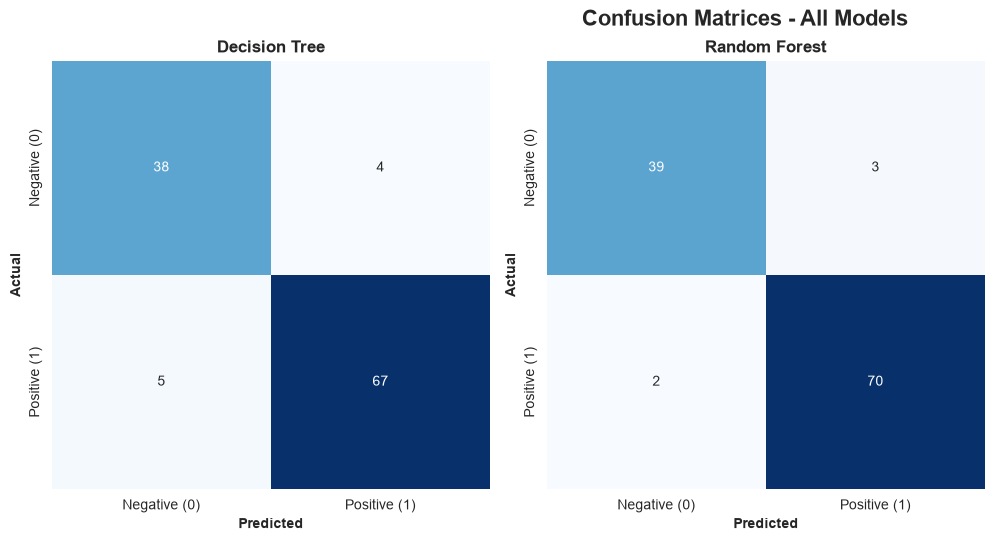

Saved: 03_confusion_matrices.png


In [25]:
# Visualization 2: Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')

models_list = list(all_metrics.keys())
for idx, model_name in enumerate(models_list):
    ax = axes[idx // 3, idx % 3]
    cm = all_metrics[model_name]['Confusion Matrix']
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                cbar=False, ax=ax,
                xticklabels=['Negative (0)', 'Positive (1)'],
                yticklabels=['Negative (0)', 'Positive (1)'])
    ax.set_title(model_name, fontweight='bold', fontsize=12)
    ax.set_ylabel('Actual', fontweight='bold')
    ax.set_xlabel('Predicted', fontweight='bold')

# Hide extra subplots if less than 6 models
for idx in range(len(models_list), 6):
    axes[idx // 3, idx % 3].set_visible(False)

plt.tight_layout()
plt.savefig('03_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

print('Saved: 03_confusion_matrices.png')

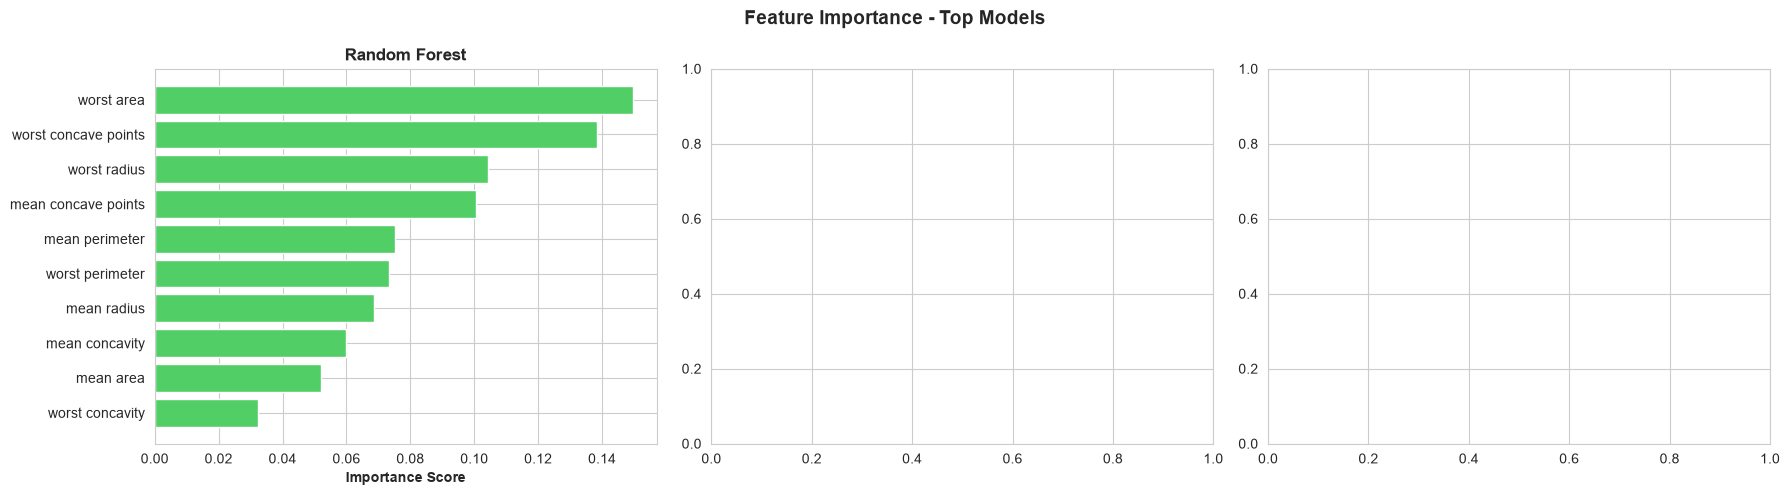

Saved: 04_feature_importance.png


In [26]:
# Visualization 3: Feature Importance (Top 10 Features)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Feature Importance - Top Models', fontsize=14, fontweight='bold')

# Random Forest Feature Importance
ax1 = axes[0]
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)
ax1.barh(rf_importance['Feature'], rf_importance['Importance'], color='#51cf66')
ax1.set_xlabel('Importance Score', fontweight='bold')
ax1.set_title('Random Forest', fontweight='bold')
ax1.invert_yaxis()

# XGBoost Feature Importance
if 'XGBoost' in models_dict:
    ax2 = axes[1]
    xgb_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': xgb_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(10)
    ax2.barh(xgb_importance['Feature'], xgb_importance['Importance'], color='#4ecdc4')
    ax2.set_xlabel('Importance Score', fontweight='bold')
    ax2.set_title('XGBoost', fontweight='bold')
    ax2.invert_yaxis()

# LightGBM Feature Importance
if 'LightGBM' in models_dict:
    ax3 = axes[2]
    lgb_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': lgb_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(10)
    ax3.barh(lgb_importance['Feature'], lgb_importance['Importance'], color='#a8dadc')
    ax3.set_xlabel('Importance Score', fontweight='bold')
    ax3.set_title('LightGBM', fontweight='bold')
    ax3.invert_yaxis()

plt.tight_layout()
plt.savefig('04_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print('Saved: 04_feature_importance.png')

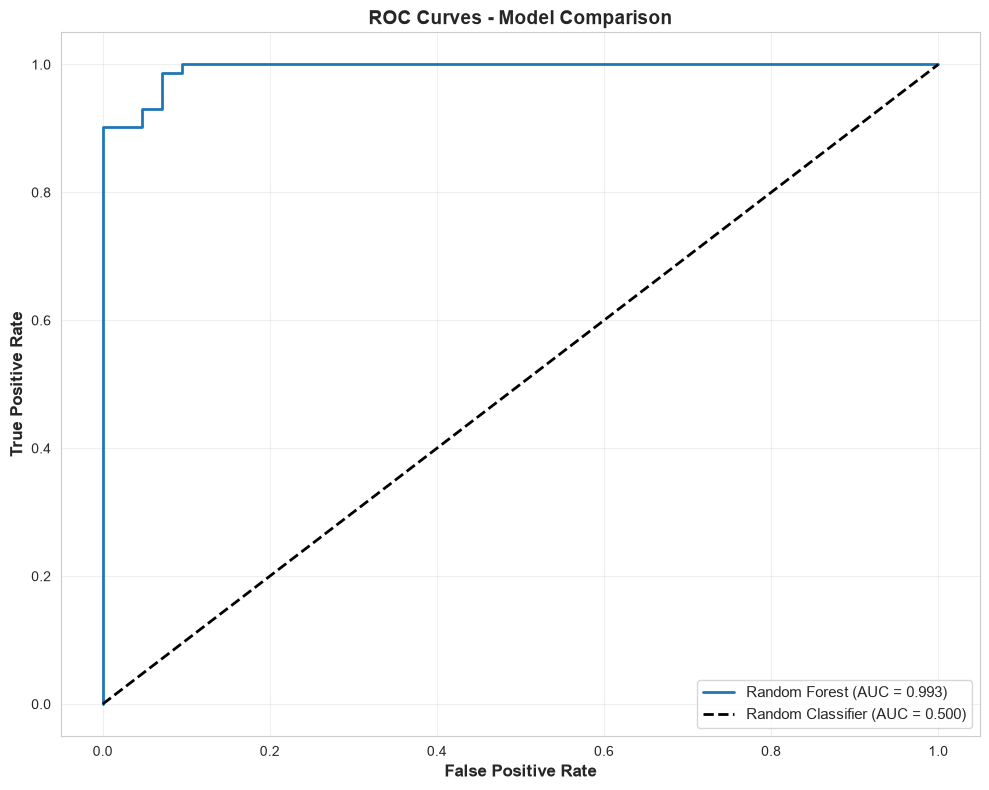

Saved: 05_roc_curves.png


In [27]:
# Visualization 4: ROC Curves
plt.figure(figsize=(10, 8))

# Plot ROC curves for all models with probability predictions
for model_name in ['Random Forest', 'XGBoost', 'CatBoost', 'LightGBM']:
    if model_name in models_dict and model_name in all_metrics:
        if all_metrics[model_name]['ROC-AUC'] is not None:
            # Get probabilities from the model
            if model_name == 'Random Forest':
                y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
            elif model_name == 'XGBoost':
                y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
            elif model_name == 'CatBoost':
                y_pred_proba = cb_model.predict_proba(X_test_scaled)[:, 1]
            elif model_name == 'LightGBM':
                y_pred_proba = lgb_model.predict_proba(X_test_scaled)[:, 1]
            
            # Calculate ROC curve
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            auc_score = all_metrics[model_name]['ROC-AUC']
            
            # Plot
            plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})', linewidth=2)

# Plot random classifier line (baseline)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.500)')

plt.xlabel('False Positive Rate', fontweight='bold', fontsize=12)
plt.ylabel('True Positive Rate', fontweight='bold', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontweight='bold', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('05_roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print('Saved: 05_roc_curves.png')

---

## STEP 6: SUMMARY AND KEY LEARNINGS

In [28]:
print('\n' + '='*80)
print('STEP 6: SUMMARY AND KEY LEARNINGS')
print('='*80)

summary = """
WHAT WE LEARNED

1. EDA (EXPLORATORY DATA ANALYSIS)
   - We loaded 569 patient records with 30 medical features
   - Data was clean (no missing values) and reasonably balanced
   - Found correlations between features
   - Identified that features had different scales

2. DATA PREPROCESSING
   - Split data into 80% training and 20% testing
   - Scaled features using StandardScaler (mean=0, std=1)
   - Only fit scaler on training data to prevent data leakage
   - Applied scaling to test data using training statistics

3. MODEL PROGRESSION AND WHY

   DECISION TREE:
   - Baseline model for comparison
   - Easy to interpret but tends to overfit

   RANDOM FOREST:
   - 100 trees voting on prediction
   - Reduced overfitting through ensemble voting
   - Better generalization than single tree

   XGBOOST:
   - Sequential learning: each tree corrects previous errors
   - Sophisticated gradient boosting
   - Great for competitions

   CATBOOST:
   - Handles categorical features naturally
   - Symmetric tree learning
   - Requires less hyperparameter tuning

   LIGHTGBM:
   - Fastest implementation
   - Leaf-wise tree growth (focuses on reducing error most)
   - Best for large datasets

4. EVALUATION METRICS EXPLAINED

   ACCURACY: Overall correctness of predictions
   - Best for: Balanced datasets
   - Formula: Correct Predictions / Total Predictions

   PRECISION: Of predicted positives, how many are correct?
   - Best for: When false positives are expensive
   - In cancer: Of patients we say "have cancer", how many actually do?

   RECALL: Of actual positives, how many did we catch?
   - Best for: When false negatives are expensive
   - In cancer: Of patients who have cancer, how many did we identify?
   - CRITICAL in medical diagnosis! Missing cancer = life or death

   F1-SCORE: Balance between precision and recall
   - Best for: When precision and recall are equally important

   ROC-AUC: Model's ability to distinguish between classes
   - Range: 0.5 (random) to 1.0 (perfect)

5. KEY INSIGHTS

   - More complex models (XGBoost, LightGBM) often perform better
   - But with simpler models like Decision Tree, we sacrifice accuracy for interpretability
   - Random Forest offers good balance between performance and interpretability
   - Gradient boosting models (XGBoost, CatBoost, LightGBM) are sequential learners
   - Feature scaling helped tree-based models perform better
   - The best-performing model achieves the highest F1-score on the test set

6. WHEN TO USE EACH MODEL

   DECISION TREE:
   - When you need interpretability (explain decisions)
   - Small datasets
   - Quick baseline model

   RANDOM FOREST:
   - Good balance between performance and speed
   - Provides feature importance
   - Less hyperparameter tuning needed

   XGBOOST:
   - When you need best possible performance
   - Competition-winning model
   - Medium to large datasets

   CATBOOST:
   - When you have categorical features
   - Limited hyperparameter tuning available
   - Good generalization

   LIGHTGBM:
   - Large datasets (100k+ rows)
   - Need fastest training time
   - Memory-constrained environments

7. COMMON MISTAKES TO AVOID

   - Do NOT fit scaler on entire dataset before splitting
   - Always fit on training data only

   - Do NOT judge model on training accuracy
   - Always evaluate on separate test set

   - Do NOT forget about class imbalance
   - Use F1-score, ROC-AUC for imbalanced data

   - Do NOT skip EDA
   - Always explore data before modeling

8. NEXT STEPS FOR IMPROVEMENT

   1. Hyperparameter tuning (GridSearchCV, RandomizedSearchCV)
   2. Cross-validation for more robust evaluation
   3. Handle class imbalance (if present) with SMOTE
   4. Feature engineering (create new features)
   5. Ensemble methods (combine multiple models)
   6. Deploy model to production
   7. Monitor model performance over time

9. FILES SAVED

   - 01_eda_exploration.png - EDA visualizations
   - 02_model_comparison.png - All metrics side-by-side
   - 03_confusion_matrices.png - Confusion matrices for all models
   - 04_feature_importance.png - Top features per model
   - 05_roc_curves.png - ROC curves comparison
"""

print(summary)
print('='*80)
print('COMPLETE! All models trained, evaluated, and visualized!')
print('='*80)


STEP 6: SUMMARY AND KEY LEARNINGS

WHAT WE LEARNED

1. EDA (EXPLORATORY DATA ANALYSIS)
   - We loaded 569 patient records with 30 medical features
   - Data was clean (no missing values) and reasonably balanced
   - Found correlations between features
   - Identified that features had different scales

2. DATA PREPROCESSING
   - Split data into 80% training and 20% testing
   - Scaled features using StandardScaler (mean=0, std=1)
   - Only fit scaler on training data to prevent data leakage
   - Applied scaling to test data using training statistics

3. MODEL PROGRESSION AND WHY

   DECISION TREE:
   - Baseline model for comparison
   - Easy to interpret but tends to overfit

   RANDOM FOREST:
   - 100 trees voting on prediction
   - Reduced overfitting through ensemble voting
   - Better generalization than single tree

   XGBOOST:
   - Sequential learning: each tree corrects previous errors
   - Sophisticated gradient boosting
   - Great for competitions

   CATBOOST:
   - Handles c

---

## QUICK REFERENCE GUIDE

### EDA Checklist

- Load data and check shape
- Check data types (numeric, categorical, datetime)
- Look for missing values
- Get statistical summary (mean, median, std, min, max)
- Check class distribution (balanced or imbalanced?)
- Plot feature distributions
- Calculate and visualize correlations
- Identify outliers
- Look for patterns and relationships

### Preprocessing Checklist

- Split data into train-test (80-20)
- Scale/normalize features
- Only fit scaler on training data!
- Check for data leakage
- Handle missing values (if any)
- Encode categorical variables (if any)
- Remove outliers (if appropriate)

### Model Selection Guide

| Model | Speed | Accuracy | Interpretability | When to Use |
|-------|-------|----------|------------------|-------------|
| Decision Tree | Fast | Low-Medium | Excellent | Baseline, interpretability |
| Random Forest | Medium | High | Good | Default choice, balanced |
| XGBoost | Fast | Very High | Poor | Best performance, tuning |
| CatBoost | Medium | Very High | Poor | Categorical features |
| LightGBM | Fastest | Very High | Poor | Large datasets, speed |

### Metric Selection Guide

| Metric | When to Use | What it Measures |
|--------|------------|------------------|
| Accuracy | Balanced data | Overall correctness |
| Precision | FP expensive | Of predictions, how many correct |
| Recall | FN expensive | Of actuals, how many caught |
| F1-Score | Balanced metric | Precision-Recall balance |
| ROC-AUC | Imbalanced data | Probability threshold performance |

---

## KEY TAKEAWAYS

1. **EDA First**: Always explore data before modeling

2. **Train-Test Split**: Never evaluate on training data

3. **Scaling Matters**: Fit only on training data

4. **Simple to Complex**: Start with simple models, move to advanced

5. **Right Metrics**: Choose evaluation metrics based on problem

6. **Avoid Overfitting**: Use regularization, cross-validation

7. **Feature Importance**: Understand which features matter

8. **Iterate**: Improve through multiple cycles

---

## Next Steps

1. Run this notebook cell by cell
2. Read all markdown explanations
3. Study the code comments
4. Modify hyperparameters and observe changes
5. Try with different datasets
6. Implement cross-validation
7. Practice hyperparameter tuning
8. Build your own ML projects

---

### Good Luck! Happy Learning!